## OR GATE PERCEPTRON

In this notebook we will implement a perceptron for the OR GATE.

Remember the `OR` gate works as follows:

| X1    | X2       | Out  |
| :-----: |:--------:| :----:|
|   0   |    0     |   0  |
|   0   |    1     |   1  |
|   1   |    0     |   1  |
|   1   |    1     |   1  |

And the corresponding perceptron is:


![Image](https://marcomilanesio.github.io/material/5/perceptron.png)

### Assign random weigths and calculate output

Let's assign the following weights at random: 
  * $w_1 = 0.2$
  * $w_2 = 0.3$
  * $w_3 = 0.5$
  
Let's assume:
  * $x_1 = 0$
  * $x_2 = 1$
  
Then we can compute:

#### input for $o_1$

\begin{align}
o_1 & = w_1 * x_1 + w_2 * x_2 + w3 * b \\
    & = 0.3 + 0.5 \\
    & = 0.8
\end{align}


#### output value (using the `sigmoid` function):

\begin{align}
out & = \frac{1}{1 + e^{-X}} = \frac{1}{1 + e^{-0.8}} = 0.68997
\end{align}

#### error (MSE):

\begin{align}
MSE & = \sum_{i} \frac{1}{2} * (target - output)^2
\end{align}

In $o_1$:

\begin{align}
err & = \frac{1}{2} * (1 - 0.68997)^2 = 0.048059
\end{align}


We need to calculate this for all possible inputs, and then calculate the global MSE.

After this, we can update the weights.
So,

## Gradient Descent

\begin{align}
X & = X - lr * \frac{\partial}{\partial X} f(X)
\end{align}

Where:
  * $X$ is the input
  * $lr$ is the learning rate
  * $f(X)$ is the output
  
### Derivation

#### N.1: how a particular weight $w$ influence the error $err$?

\begin{align}
\frac{\partial err}{\partial w}
\end{align}


Let's apply [Chain Rule](https://en.wikipedia.org/wiki/Chain_rule).

\begin{align}
\frac{\partial err}{\partial w} = \frac{\partial err}{\partial out} * \frac{\partial out}{\partial in} * \frac{\partial in}{\partial w}
\end{align}

Where (I'll skip the derivation, if interested ask me)

  * $\frac{\partial err}{\partial out} = (output - target)$
  * $\frac{\partial out}{\partial in} = output * (1 - output)$
  * $\frac{\partial in}{\partial w} = input$

And remember:
  * $input = w_1 * x_1 + w_2 * x_2 + w_3 * b$
  * $output = \frac{1}{1 + e^{-input}}$
  * $MSE = \sum \frac{1}{2} (target - output)^2$
  * Gradient Descent $w = w - lr * \frac{\partial err}{\partial w}$
  
  
## LET'S DO IT!

Let's create input and target.

In [1]:
import numpy as np
input_features = np.array([[0,0], [0,1], [1,0], [1,1]])
target_output = np.array([[0,1,1,1]])

In [2]:
input_features

array([[0, 0],
       [0, 1],
       [1, 0],
       [1, 1]])

In [3]:
target_output

array([[0, 1, 1, 1]])

In [4]:
input_features.shape

(4, 2)

In [5]:
target_output.shape

(1, 4)

In [6]:
target_output = target_output.reshape(4,1)

In [7]:
target_output.shape

(4, 1)

In [49]:
weights = np.array([[0.1], [0.2]])

In [9]:
weights.shape

(2, 1)

In [48]:
bias = 0.3  # bias weight
lr = 25   # learning rate

In [11]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

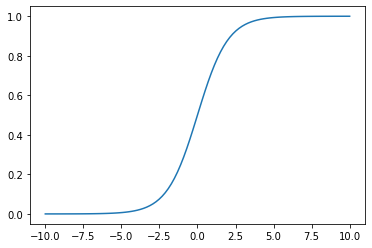

In [12]:
import matplotlib.pyplot as plt

in_ = np.linspace(-10, 10, 100)
plt.plot(in_, sigmoid(in_))

In [13]:
def sigmoid_derivative(x):
    return sigmoid(x) * (1 - sigmoid(x))

In [50]:
errors = []

for epoch in range(10000):
    # input
    inputs = input_features
    # feed-forward input
    in_o = np.dot(inputs, weights)  # shape (4,2) dot shape (2,1) --> np.dot is of shape (4,1)
    # feed-forward output
    out_o = sigmoid(in_o)   # --> res in (0,1) range
    
    # backpropagation
    error = out_o - target_output
    x = error.sum()  # NOT THE MSE!!!!! 
    errors.append(x)
    
    if epoch % 1000 == 0:
        print(f'epoch {epoch}. Error {x}')
    
    # update weights
    derr_dout = error    # 1st deriv
    dout_din = sigmoid_derivative(out_o)  # 2nd deriv
    
    deriv = derr_dout * dout_din   # shape (4,1)
    
    inputs = input_features.T   # 3rd deriv
    deriv_final = np.dot(inputs, deriv)  # THAT's what we were looking for  # shape (2,1)
    
    
    weights -= lr * deriv_final


epoch 0. Error -0.850744298396923
epoch 1000. Error 0.49960934716036987
epoch 2000. Error 0.49980073535276537
epoch 3000. Error 0.499866250859765
epoch 4000. Error 0.4998993431950721
epoch 5000. Error 0.4999193074657712
epoch 6000. Error 0.4999326628060359
epoch 7000. Error 0.49994222494020224
epoch 8000. Error 0.49994940896934315
epoch 9000. Error 0.49995500394381154


In [46]:
print(weights)

[[8.50149017]
 [8.50155237]]


In [47]:
error

array([[ 5.00000000e-01],
       [-2.03131776e-04],
       [-2.03144409e-04],
       [-4.12818529e-08]])

## PREDICTIONS

In [40]:
# prediction for (1,0) --> target = 1
point = np.array([1,0])
step1 = np.dot(point, weights) + bias   # apply the formula to calculate the input
step2 = sigmoid(step1)                  # calculate the output as per activation function
print(step2)

[0.99925022]


In [41]:
# prediction for (1,1) --> target = 1
point = np.array([1,1])
step1 = np.dot(point, weights) + bias
step2 = sigmoid(step1)
print(step2)

[0.99999924]


In [42]:
# prediction for (0, 0) --> target = 0
point = np.array([0,0])
step1 = np.dot(point, weights) + bias
step2 = sigmoid(step1)
print(step2)

[0.57444252]


## bias vs sigmoid shape

In [21]:
test_input = np.linspace(-10, 10, 100)

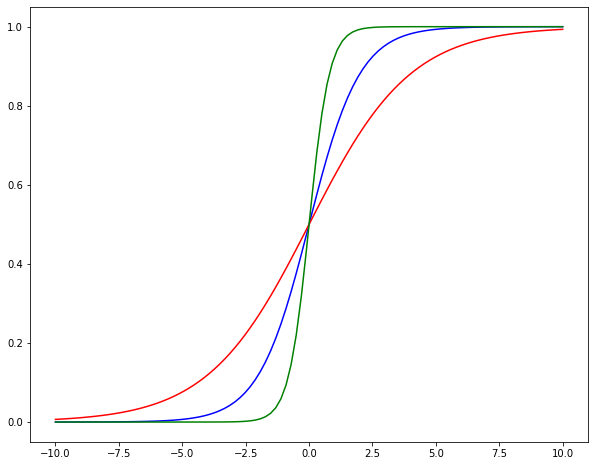

In [24]:
# b = something in the perceptron
plt.rcParams['figure.figsize'] = (10, 8)
plt.plot(test_input, sigmoid(test_input * 1), c='b')
plt.plot(test_input, sigmoid(test_input * 0.5), c='r')
plt.plot(test_input, sigmoid(test_input * 2.5), c='g')

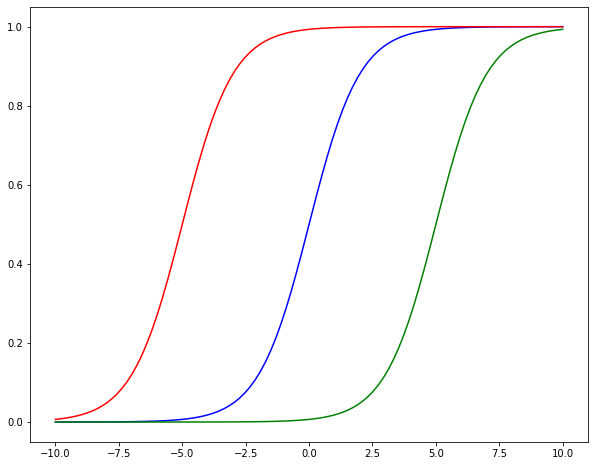

In [25]:
plt.plot(test_input, sigmoid(test_input), c='b')
plt.plot(test_input, sigmoid(test_input + 5), c='r')
plt.plot(test_input, sigmoid(test_input - 5), c='g')